# 02 — Forecasting and Spreads Demo

This notebook demonstrates Section 6 forecasting/spread artifacts and OOS model-comparison outputs.

In [6]:
from pathlib import Path
from IPython.display import Image, display, Markdown
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
TABLES = ROOT / 'project report' / 'tables'
GRAPHICS = ROOT / 'project report' / 'graphics'

required = [
    GRAPHICS / 'fig_6_1_spreads.png',
    GRAPHICS / 'fig_6_2_ns_residuals.png',
    TABLES / 'tab_6_1_ns_metrics.tex',
    TABLES / 'tab_6_2_abnormal.tex',
    TABLES / 'tab_6_3_model_comparison_ru.csv',
    TABLES / 'tab_6_3_model_comparison_cn.csv',
    TABLES / 'tab_6_3_model_comparison_best_model.csv',
    TABLES / 'tab_6_3_model_comparison_avg_rmse.png',
]
missing = [p for p in required if not p.exists()]
print(f'Missing artifacts: {len(missing)}')
for p in missing:
    print(' -', p)

Missing artifacts: 0


## Baseline Spread and Residual Figures

### fig_6_1_spreads.png

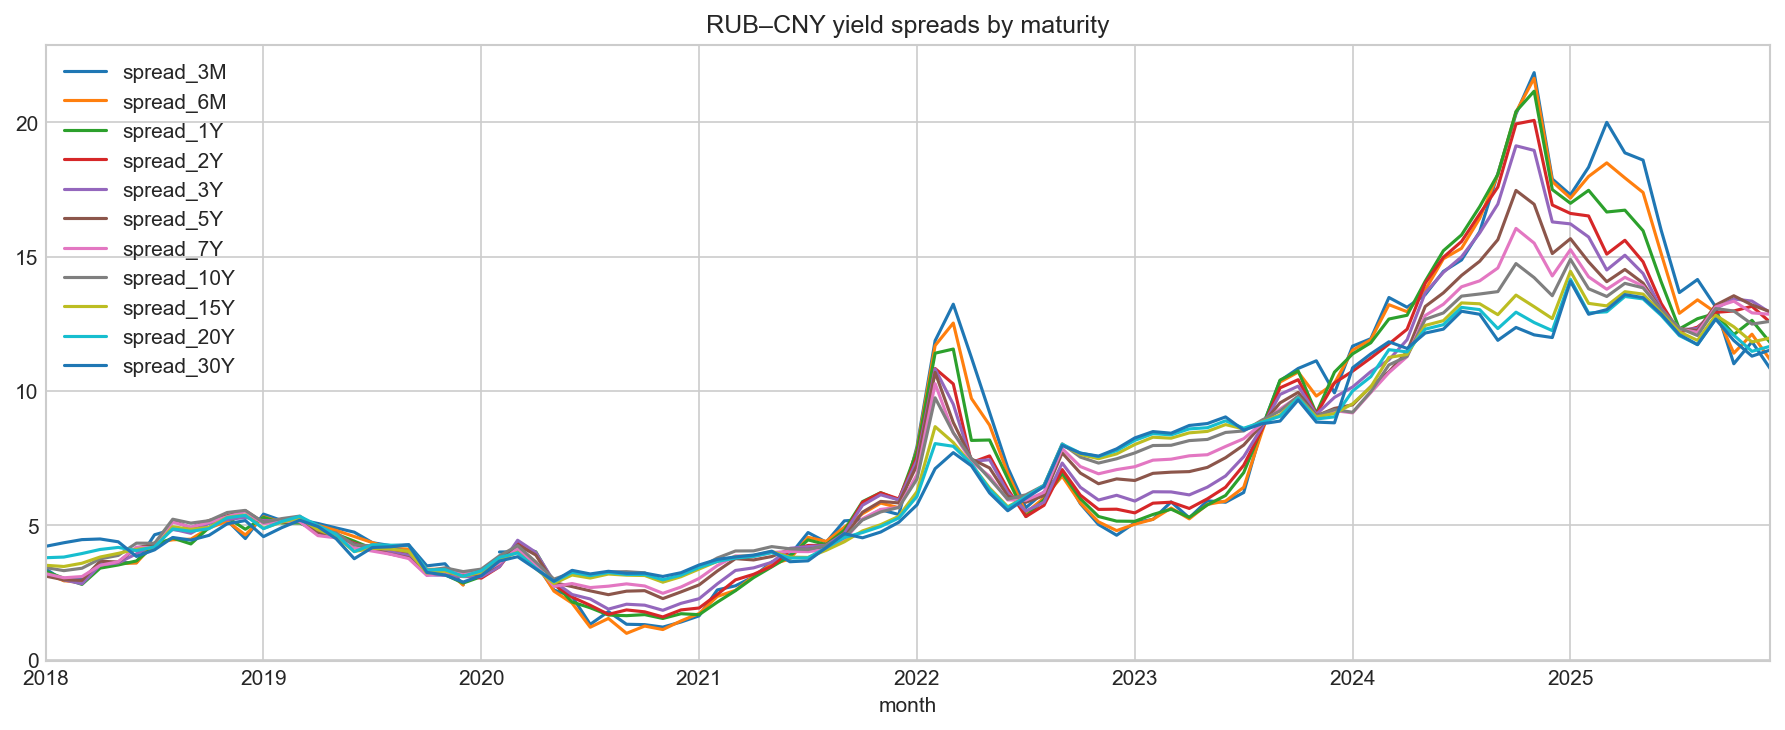

### fig_6_2_ns_residuals.png

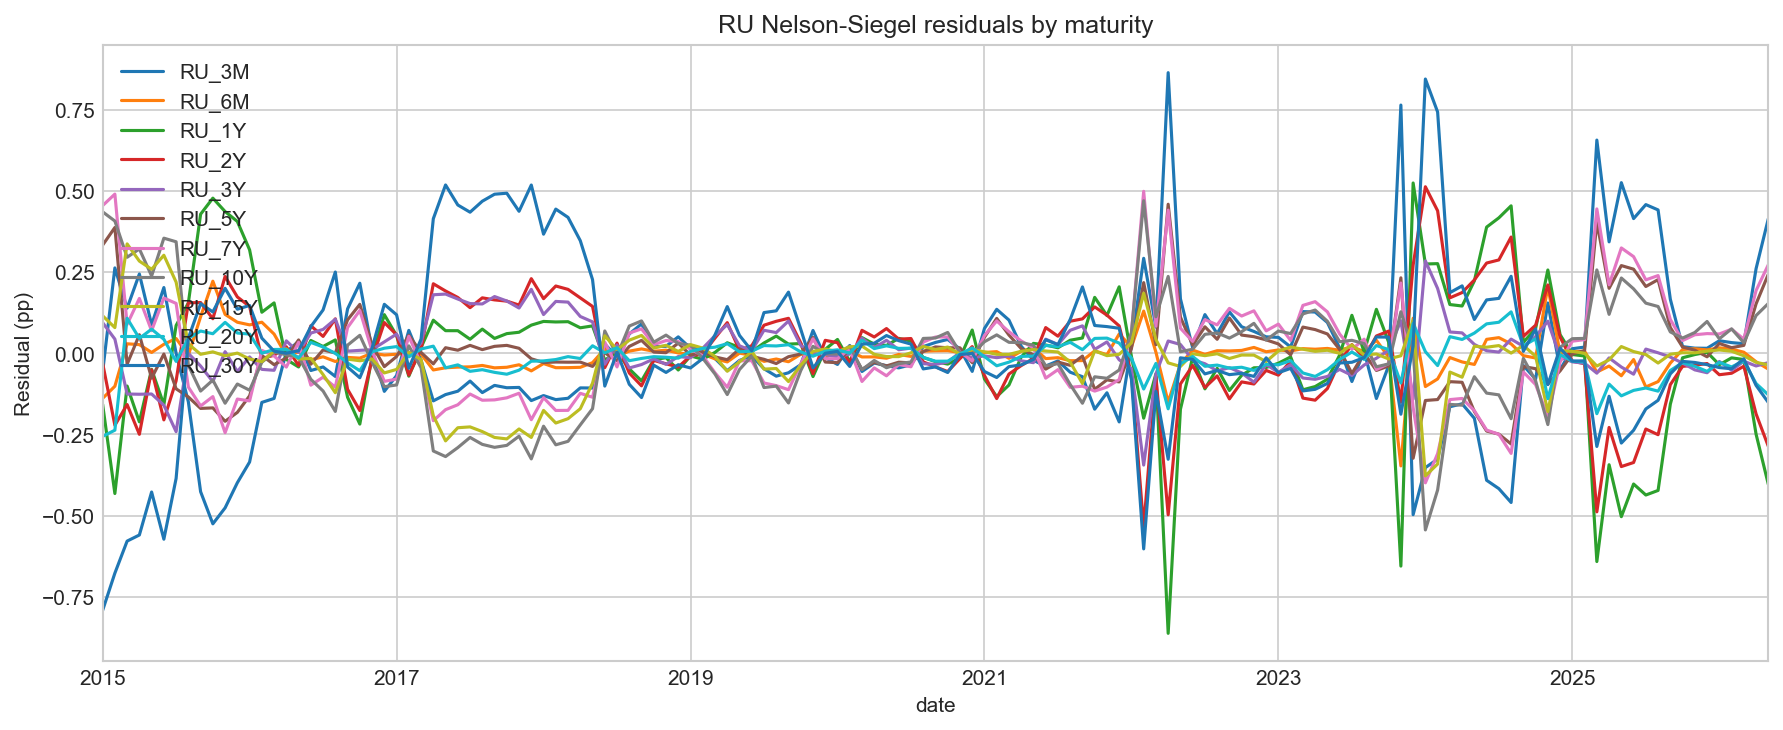

In [7]:
for name in ['fig_6_1_spreads.png', 'fig_6_2_ns_residuals.png']:
    p = GRAPHICS / name
    display(Markdown(f'### {name}'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f'Missing: {p}')

## NS Metrics and Abnormal Spread Tables

In [8]:
for name in ['tab_6_1_ns_metrics.tex', 'tab_6_2_abnormal.tex']:
    p = TABLES / name
    display(Markdown(f'### {name}'))
    if p.exists():
        text = p.read_text(encoding='utf-8', errors='ignore')
        print(text[:2500] + ('\n... [truncated]' if len(text) > 2500 else ''))
    else:
        print(f'Missing: {p}')

### tab_6_1_ns_metrics.tex

\begin{table}
\caption{NS fit metrics}
\label{tab:6_1}
\begin{tabular}{llrr}
\toprule
Currency & Maturity & MAE & RMSE \\
\midrule
RU & RU_3M & 0.1379 & 0.2112 \\
RU & RU_6M & 0.0329 & 0.0575 \\
RU & RU_1Y & 0.1276 & 0.2027 \\
RU & RU_2Y & 0.1195 & 0.1611 \\
RU & RU_3Y & 0.0596 & 0.0842 \\
RU & RU_5Y & 0.0740 & 0.1174 \\
RU & RU_7Y & 0.1162 & 0.1542 \\
RU & RU_10Y & 0.1157 & 0.1608 \\
RU & RU_15Y & 0.0585 & 0.1059 \\
RU & RU_20Y & 0.0426 & 0.0609 \\
RU & RU_30Y & 0.1562 & 0.2416 \\
CN & CN_10Y & 0.1218 & 0.1373 \\
CN & CN_15Y & 0.0226 & 0.0271 \\
CN & CN_1Y & 0.0588 & 0.0766 \\
CN & CN_20Y & 0.0318 & 0.0423 \\
CN & CN_2Y & 0.0575 & 0.0679 \\
CN & CN_30Y & 0.0804 & 0.0926 \\
CN & CN_3M & 0.0715 & 0.0955 \\
CN & CN_3Y & 0.0311 & 0.0396 \\
CN & CN_5Y & 0.0306 & 0.0392 \\
CN & CN_6M & 0.0379 & 0.0571 \\
CN & CN_7Y & 0.0321 & 0.0428 \\
CN & CN_9M & 0.0364 & 0.0545 \\
\bottomrule
\end{tabular}
\end{table}



### tab_6_2_abnormal.tex

\begin{table}
\caption{Abnormal spread flags (Z>2)}
\label{tab:6_2}
\begin{tabular}{lr}
\toprule
Maturity & Count \\
\midrule
3M & 11 \\
6M & 9 \\
1Y & 6 \\
2Y & 5 \\
3Y & 7 \\
5Y & 5 \\
7Y & 7 \\
10Y & 7 \\
15Y & 9 \\
20Y & 9 \\
30Y & 10 \\
\bottomrule
\end{tabular}
\end{table}



## OOS Model Comparison (RU/CN)

In [9]:
ru = pd.read_csv(TABLES / 'tab_6_3_model_comparison_ru.csv', index_col=0)
cn = pd.read_csv(TABLES / 'tab_6_3_model_comparison_cn.csv', index_col=0)
best = pd.read_csv(TABLES / 'tab_6_3_model_comparison_best_model.csv')

print('RU RMSE matrix:')
display(ru)
print('CN RMSE matrix:')
display(cn)
print('Best model by maturity:')
display(best.head(30))

RU RMSE matrix:


,RW,NS_static,DNS,PCA,VAR
maturity,,,,,
RU_3M,1.3336,1.2314,1.2898,1.3336,1.8896
RU_6M,1.1981,1.1993,1.2877,1.1981,1.9160
RU_1Y,1.1074,1.1679,1.2973,1.1074,1.9878
RU_2Y,0.9770,1.0218,1.1750,0.9770,1.9496
RU_3Y,0.8949,0.9043,1.0449,0.8949,1.8254
RU_5Y,0.7998,0.7823,0.8845,0.7998,1.5432
RU_7Y,0.7337,0.7123,0.7953,0.7337,1.3138
RU_10Y,0.6578,0.6366,0.7103,0.6578,1.1161
RU_15Y,0.6005,0.5911,0.6527,0.6005,1.0235


CN RMSE matrix:


,RW,NS_static,DNS,PCA,VAR
maturity,,,,,
CN_10Y,0.0957,0.1141,0.1050,0.0957,0.1773
CN_15Y,0.0912,0.0948,0.0993,0.0912,0.1464
CN_1Y,0.1249,0.1262,0.1395,0.1249,0.2746
CN_20Y,0.0959,0.1044,0.1177,0.0959,0.1371
CN_2Y,0.1041,0.1078,0.1351,0.1041,0.2579
CN_30Y,0.1060,0.1166,0.1167,0.1060,0.1583
CN_3M,0.1972,0.1884,0.1937,0.1972,0.3538
CN_3Y,0.1046,0.1063,0.1247,0.1046,0.2388
CN_5Y,0.0918,0.0974,0.1037,0.0918,0.2153


Best model by maturity:


,Curve,Maturity,BestModel
0,RU,RU_3M,NS_static
1,RU,RU_6M,RW
2,RU,RU_1Y,RW
3,RU,RU_2Y,RW
4,RU,RU_3Y,RW
5,RU,RU_5Y,NS_static
6,RU,RU_7Y,NS_static
7,RU,RU_10Y,NS_static
8,RU,RU_15Y,NS_static
9,RU,RU_20Y,RW


### Average OOS RMSE by Model

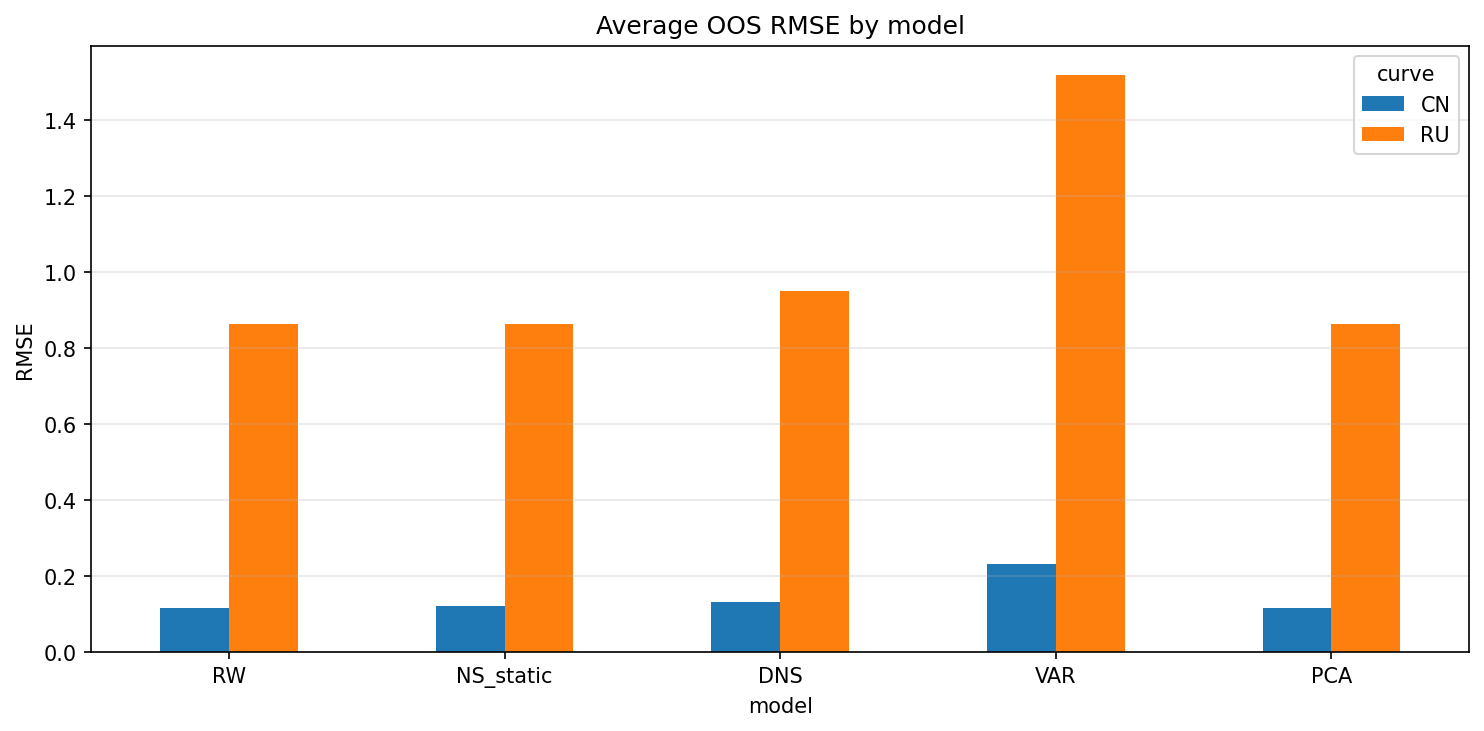

In [10]:
avg_img = TABLES / 'tab_6_3_model_comparison_avg_rmse.png'
display(Markdown('### Average OOS RMSE by Model'))
if avg_img.exists():
    display(Image(filename=str(avg_img)))
else:
    print(f'Missing: {avg_img}')

## Interpretation prompts

- Which model family dominates by maturity bucket?
- Does dominance differ between RU and CN curves?
- How does this inform signal construction in notebook 03?

In [ ]:
# Major results summary (forecasting + spreads)
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
TABLES = ROOT / 'project report' / 'tables'

ru_path = TABLES / 'tab_6_3_model_comparison_ru.csv'
cn_path = TABLES / 'tab_6_3_model_comparison_cn.csv'
best_path = TABLES / 'tab_6_3_model_comparison_best_model.csv'
adv_path = TABLES / 'tab_6_4_advanced_methods.csv'

if not (ru_path.exists() and cn_path.exists() and best_path.exists()):
    display(Markdown('**Major-results summary unavailable:** missing model-comparison exports.'))
else:
    ru = pd.read_csv(ru_path, index_col=0)
    cn = pd.read_csv(cn_path, index_col=0)
    best = pd.read_csv(best_path)

    ru_means = ru.mean(axis=0, numeric_only=True)
    cn_means = cn.mean(axis=0, numeric_only=True)
    avg_rmse = pd.DataFrame({
        'RU_avg_rmse': ru_means,
        'CN_avg_rmse': cn_means
    })
    avg_rmse['Both_curves_avg'] = avg_rmse.mean(axis=1)
    avg_rmse = avg_rmse.sort_values('Both_curves_avg')

    best_counts = best.groupby(['Curve', 'BestModel']).size().reset_index(name='wins')

    display(Markdown('## Major Results — Forecasting'))
    display(Markdown('### Average RMSE by model (lower is better)'))
    display(avg_rmse.round(4))

    display(Markdown('### Best-model wins by curve and maturity buckets'))
    display(best_counts.sort_values(['Curve', 'wins'], ascending=[True, False]))

if adv_path.exists():
    adv = pd.read_csv(adv_path)
    display(Markdown('### Advanced methods diagnostic (reference)'))
    display(adv)